# Introduction

## Agents, Uncertainty, and Decisions

An agent is an autonomous entity that observes aspect of its environment and that can choose to perform certain actions on it. Examples for this include:

1. An investor that observes the investment market to choose which investment to perform.
2. A vehicle that observes its sensor inputs to decide whether or not to change the driving direction or speed.
3. A personal assistant that observes incoming messages to decide which of them to forward to the client.

The central question of this course is: how to design agents that 

1. make good decisions in an uncertain environment and that 
2. improve with experience?

In this module we will mainly focus on the first question. The second question will then be discussed in the most of the remainder of the course.

## Aleatoric and Epistemic Uncertainty

In typical environments, agents face two different kinds of uncertainty: 

1. Non-deterministic mechanisms.
    
    Relates to the data / observations recorded by the agent (e.g., through noisy measurement devices) as well as to the outcome of actions.

    Called **aleatoric uncertainty** from Latin *alea* for "die" as in the famous quote of Suetonius to Iulius Ceasar *alea iacta est* ("the die is cast/thrown") at the start of the Roman civil war.

    Example: outcome of next player's dice roll in Backgammon

    Characteristic: can *not* be reduced by collecting more data / observations

2. Lack of knowledge. 

    Relates to quantities in the world that are principally deterministic, just not known to the agent. 
    
    Called **epistemic uncertainty** from Greek *epsisteme* for "knowledge".

    Example: location of Uganda on a map of Africa

    Characteristic: can typically be reduced by appropriate data collection and processing (more on that later)

<table style="margin-left: auto; margin-right: auto;">
  <tr>
    <td align="center">
      <img src="images/snake_eyes_dice.jpg" height="200">
    </td>
    <td align="center">
      <img src="images/africa.jpg" height="200">
    </td>
  </tr>
  <tr style="text-align: center;">
    <td><b>Aleatoric Uncertainty</b><br>(Outcome of die roll)</td>
    <td><b>Epistemic Uncertainty</b><br>(Location of Uganda)</td>
  </tr>
</table>

**Question:** For each of the following facts/quantities, discuss whether there are aleatoric and/or epistemic uncertainties.

1. The capital of Kazakhstan
2. The position of an electron orbiting an atomic core
3. The outcome of a spin of a roulette wheel
4. The distance to another car driving in front of an autonomous vehicle
5. The net worth of a specific company in two years
6. The net worth of a specific company ten years ago


## Probability

Probability spaces are the abstract mathematical model of uncertainty / randomness. A probability space consists of 

1. A set of possible elementary **outcomes** $\Omega$ also called **sample space**,  
    Example: The sample space corresponding to the possible outcomes of rolling two six-sided dies is $\Omega=\{(a, b): a,b \in \{1, 2, 3, 4, 5, 6\}\}$.
2. A set of "measurable" **events** $\mathcal F$ each of which is a subset of the elementary outcomes.  
    Meaning: We say that $F \in \mathcal F$ occurred if  
    Example: The event of the sum of the two die roles is even is given as $F=\{(a, b): a+b \text{ is even}\}$

3. A probability measure $\Pr: \mathcal F \to [0, 1]$ that quantifies how "probable" the occurrence of an event is.


Th
1. Unity: $\Pr(\Omega)=1$, meaning it is certain that some outcome will occur
2. Additivity: for events $E_1, E_2, \dots \in \mathcal F$ that are mutually exclusive, i.e., $E_i \cap E_j = \emptyset$ the probabilities add up, i.e., $$\Pr(E_1 \cup E_2 \cup \dots)=\Pr(E_1)+\Pr(E_2)+\dots$$

## Scenario: Investment

Assume an agent can choose to invest $\$1000$ either in

1. **Action $a_1$:** bonds of a company that return $\$1500$ in two years if the company did not go bankrupt (state of environment $\theta_1$) or nothing if it did ($\theta_2$); or
2. a safe investment that surely returns $\$1300$ 

This situation results in the loss function $\ell(\theta, a)$ given by the following table:

$\ell$ | $a_1$ | $a_2$ 
:---  | ---: | ---: 
$\theta_1$ | -500 | -300 
$\theta_2$ | 1000 | -300 


$\theta \sim \mathrm{MultiNom}(0.5, 0.5)$

$$
\begin{aligned}
L(a_1) &= 0.5\cdot(-500)+0.5\cdot 1000 = 250\\
L(a_2) &= -300
\end{aligned}
$$

[[-500 -300]
 [1000 -300]]


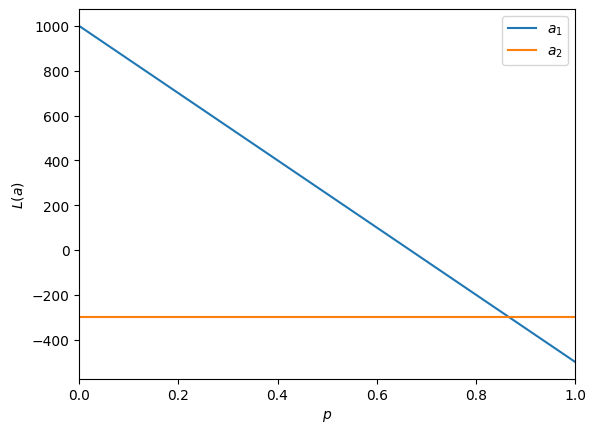

In [40]:
from matplotlib import pyplot as plt
import numpy as np

loss_matrix = np.array([[-500, -300], [1000, -300]])
print(loss_matrix)

def expected_loss(a, p):
    return loss_matrix[0, a]*p + (1-p)*loss_matrix[1, a]

ps = np.linspace(0, 1, 200)
plt.plot(ps, expected_loss(0, ps), label='$a_1$')
plt.plot(ps, expected_loss(1, ps), label='$a_2$')
plt.xlabel('$p$')
plt.ylabel('$L(a)$')
plt.legend()
plt.margins(x=0)
plt.show()

## Utility



np.float64(0.015698833992807113)

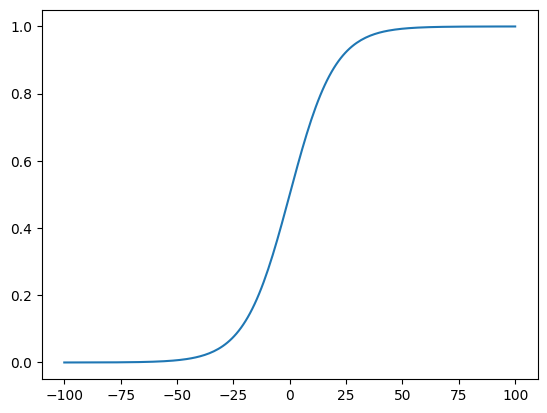

In [96]:
def utility(r, alpha=0.1):
    return 1 / (1+np.exp(-alpha*r))# 10*np.log2(w+2*r+1)

def expected_utility(c, terms=50):
    res = 0
    for i in range(1, terms+1):
        res += utility(2**i - c) / 2**i
    return res

rs = np.linspace(-100, 100, 200)

plt.plot(rs, utility(rs))
expected_utility(100)

In [73]:
from scipy.optimize import fsolve

def u_sigmoid(w, alpha=0.01):
    return 1 / (1 + np.exp(-alpha * w))

def objective(c, W=-1000):
    expected_u = sum(u_sigmoid(W + 2**i - c) / 2**i for i in range(1, 40))
    return expected_u - u_sigmoid(W)

fair_price = fsolve(objective, x0=0)[0]
fair_price

/var/folders/zw/qxvhv2ms1rx684818_y1cvl40000gn/T/ipykernel_3680/1574370303.py:10: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  fair_price = fsolve(objective, x0=0)[0]


np.float64(20228.289795831435)

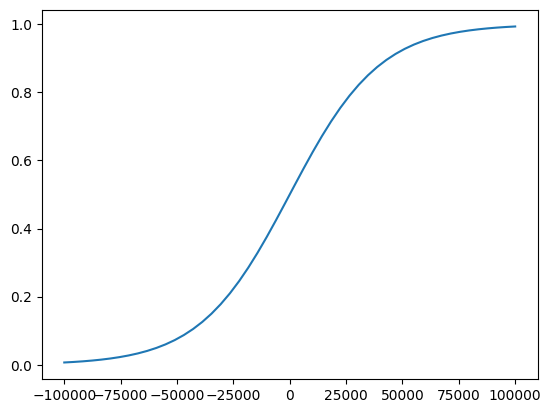

In [63]:
rs = np.linspace(-100000, 100000)
plt.plot(rs, u_sigmoid(rs, alpha=0.00005))

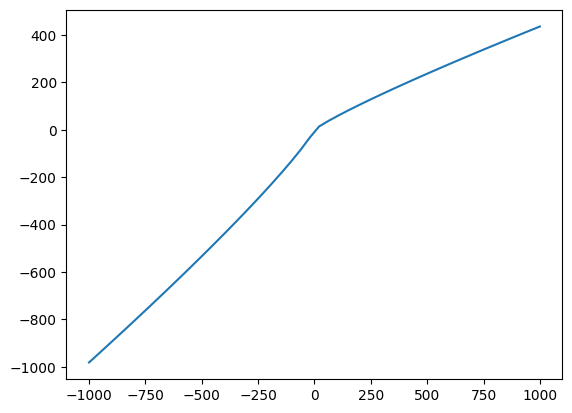

In [97]:
def prospect_utility(x, alpha=0.88, beta=0.88, lam=2.25):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    np.power(x, alpha, where=x >= 0, out=out)
    np.power(-x, beta, where=x<0, out=out)
    np.multiply(out, -lam, where=x<0, out=out)
    return out

rs = np.linspace(-1000, 1000)
plt.plot(rs, prospect_utility(rs))

## Scenario: Production Volume

$$
\ell(\theta, a) =
\begin{cases}
\theta - a & \text{, } \theta \geq a \\
2(a - \theta ) & \text{, otherwise} 
\end{cases}
$$

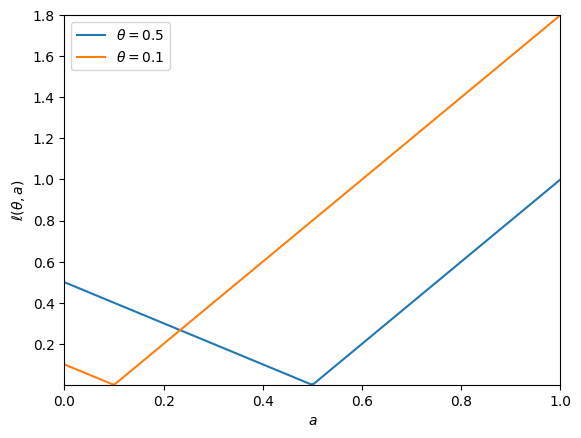

In [32]:
from matplotlib import pyplot as plt
import numpy as np

def loss(theta, a):
    return (theta >= a)*(theta - a) + (theta < a)*2*(a - theta)

xs = np.linspace(0, 1, 200, endpoint=True)
plt.plot(xs, loss(0.5, xs), label=r'$\theta=0.5$')
plt.plot(xs, loss(0.1, xs), label=r'$\theta=0.1$')
plt.xlabel('$a$')
plt.ylabel(r'$\ell(\theta,a)$')
plt.margins(x=0, y=0)
plt.legend()
plt.show()

### Bayesian Expected Loss

Using the definition of our loss function, we can decompose the Bayesian expected loss as
$$
\begin{aligned}
L(a) &= \bold{E}(\ell(\theta, a))\\
&= \bold{E}(\theta - a \mid \theta \geq a)\Pr(\theta \geq a) + \bold E(2(a-\theta) \mid \theta < a)\Pr(\theta < a) \enspace .
\end{aligned}
$$

Let us assume we believe $\theta \sim \mathrm{Unif}(0.1, 0.2)$. Then we can further analyse the above expression via a case distinction on $a$. 

**Case $a < 0.1$**: 

This case is simple, because it implies $\Pr(\theta \geq a)=1$, $\Pr(\theta < a)=0$, and $\bold{E}(\theta \mid \theta \geq a)=\bold E(\theta)=0.15$. If follows that $L(a)=0.15 - a$.

**Case $a > 0.2$**:

This case is similarly simply, because it implies $\Pr(\theta \geq a)=0$, $\Pr(\theta < a)=1$, and again $\bold{E}(\theta \mid \theta < a)=\bold E(\theta)=0.15$. It follows that $L(a)=2(a - \bold E(\theta \mid a > \theta))=2a - 0.3$.

**Case $0.1 \leq a \leq 0.2$**:

This final case is a bit more complicated, but still managable. 

1. $\Pr(\theta \geq a) = 10(0.2 - a)$
2. $\Pr(\theta < a) = 10(a - 0.1)$
3. $\Pr(\theta \mid \theta \geq a) = (0.2 - a)/2$
4. $\Pr(\theta \mid \theta < a)=(a - 0.1)/2$

It follows that 
$$
\begin{aligned}
L(a) &= 5(0.2 - a)^2 + 10(a-0.1)^2\\
&= 5a^2 + 0.2 - 2a + 10a^2 + 0.1 - 2a\\
&= 15a^2 - 4a + 0.3
\end{aligned}
$$

Summarising the three different cases yields:
$$
L(a) =
\begin{cases}
0.15 - a & \text{, } a < 0.1\\
15a^2 - 4a + 0.3 & \text{, } 0.1 \leq a \leq 0.2\\
2a - 0.3 & \text{, otherwise}
\end{cases}
$$

Further, with basic calculus we can show that the optimal action is $a^*=2/15$ with a Bayesian expected loss of $L(a^*)=1/30$

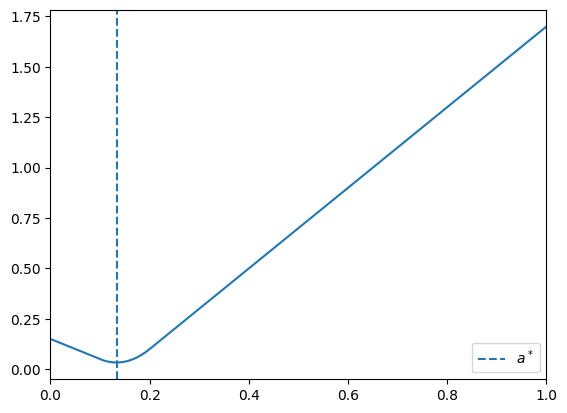

In [33]:
def bayes_expected_loss(a):
    return (0.15-a)*(a<0.1) + (15*a**2 - 4*a + 0.3)*((a >= 0.1) & (a<= 0.2)) + (2*a-0.3)*(a>0.2)

plt.plot(xs, bayes_expected_loss(xs))
plt.axvline(2/15, ls='--', label='$a^*$')
plt.margins(x=0)
plt.legend()
plt.show()